In [1]:
import requests
import pandas as pd
import time
from tqdm import tqdm
import re
import spacy
import numpy as np
from spacy.matcher import PhraseMatcher

## Data Acquisition

In [2]:
API_KEY = "84287db0-182f-4d1b-9d8e-3c2047664fe4"

In [3]:
BASE_URL = "https://content.guardianapis.com/search"

params = {
    "api-key": API_KEY,
    "section": "commentisfree",
    "from-date": "2019-01-01",
    "to-date": "2024-12-31",
    "show-fields": "bodyText,headline,byline",
    "show-tags": "type,keyword,tone",
    "page-size": 50,   # maximum allowed
    "page": 1
}

In [4]:
response = requests.get(BASE_URL, params=params)

print("Status code:", response.status_code)
print(response.url)

data = response.json()

Status code: 200
https://content.guardianapis.com/search?api-key=84287db0-182f-4d1b-9d8e-3c2047664fe4&section=commentisfree&from-date=2019-01-01&to-date=2024-12-31&show-fields=bodyText%2Cheadline%2Cbyline&show-tags=type%2Ckeyword%2Ctone&page-size=50&page=1


In [5]:
all_articles = []

# First request to get total pages
response = requests.get(BASE_URL, params=params)
data = response.json()

total_pages = data["response"]["pages"]
print(f"Total pages in 2019-2024 in commentisfree section: {total_pages}")

for page in tqdm(range(1, total_pages + 1)):
    params["page"] = page
    
    response = requests.get(BASE_URL, params=params)
    data = response.json()
    
    articles = data["response"]["results"]
    
    for article in articles:
        fields = article.get("fields", {})
        
        all_articles.append({
            "webTitle": article.get("webTitle"),
            "sectionName": article.get("sectionName"),
            "webPublicationDate": article.get("webPublicationDate"),
            "headline": fields.get("headline"),
            "byline": fields.get("byline"),
            "bodyText": fields.get("bodyText"),
            "tags": article.get("tags"),
            "webUrl": article.get("webUrl")
        })
    
    time.sleep(1)

Total pages in 2019-2024 in commentisfree section: 662


100%|████████████████████████████████████████████████████████████████████████████████| 662/662 [13:41<00:00,  1.24s/it]


In [6]:
df = pd.DataFrame(all_articles)

print("Total articles pulled:", len(df))

Total articles pulled: 33067


In [7]:
df.head()

,webTitle,sectionName,webPublicationDate,headline,byline,bodyText,tags,webUrl
0,"Sharp and curious, my 85-year-old neighbour wa...",Opinion,2024-12-31T23:00:57Z,"Sharp and curious, my 85-year-old neighbour wa...",Nova Weetman,My friendships have mostly been with people of...,"[{'id': 'lifeandstyle/friendship', 'type': 'ke...",https://www.theguardian.com/commentisfree/2025...
1,This is some of what we must do to reform our ...,Opinion,2024-12-31T19:59:11Z,This is some of what we must do to reform our ...,Bernie Sanders,"Over the past year, I’ve had the privilege of ...","[{'id': 'us-news/bernie-sanders', 'type': 'key...",https://www.theguardian.com/commentisfree/2024...
2,The Guardian view on Labour’s NHS reform: stru...,Opinion,2024-12-31T18:30:52Z,The Guardian view on Labour’s NHS reform: stru...,Editorial,The British government’s 10-year health plan i...,"[{'id': 'society/nhs', 'type': 'keyword', 'sec...",https://www.theguardian.com/commentisfree/2024...
3,Two-thirds of workers in England can’t afford ...,Opinion,2024-12-31T15:00:49Z,Two-thirds of workers in England can’t afford ...,Phineas Harper,"This Christmas, bailiffs have been busy. Evict...","[{'id': 'society/social-housing', 'type': 'key...",https://www.theguardian.com/commentisfree/2024...
4,‘Sex strikes’ aren’t the feminist win they app...,Opinion,2024-12-31T14:00:50Z,‘Sex strikes’ aren’t the feminist win they app...,Finn Mackay,"Since Trump’s election win in the US, the idea...","[{'id': 'world/feminism', 'type': 'keyword', '...",https://www.theguardian.com/commentisfree/2024...


In [8]:
row = df.iloc[0]

for col in df.columns:
    print(f"{col}: {row[col]}")

webTitle: Sharp and curious, my 85-year-old neighbour wades into conversations with a joyful openness | Nova Weetman
sectionName: Opinion
webPublicationDate: 2024-12-31T23:00:57Z
headline: Sharp and curious, my 85-year-old neighbour wades into conversations with a joyful openness
byline: Nova Weetman
bodyText: My friendships have mostly been with people of a similar age, but that all changed when my 85-year-old neighbour left a CD in my letterbox after hearing my young son drumming wildly in our garage. She wrapped the CD in a note written in her finest hand, explaining that she thought he might enjoy the sounds of her friend’s band, The Necks. Others in our street had understandably complained about the endless noise because the sound reverberated through their walls, creeping into their quiet spaces, and ruining their days. But my neighbour did not. She delighted in it, sometimes standing outside our garage door and listening to him bash away at a song like it was her private concert

## Exploratory Data Analysis (EDA)

In [9]:
df.describe(include="all")

,webTitle,sectionName,webPublicationDate,headline,byline,bodyText,tags,webUrl
count,33067,33067,33067,33067,32947,33067,33067,33067
unique,33059,1,32199,33057,6240,32444,32145,33066
top,Who won the Democrats' debate? Our panelists' ...,Opinion,2019-11-17T06:30:09Z,Who won the Democratic debate? Our panelists' ...,Editorial,,"[{'id': 'type/article', 'type': 'type', 'webTi...",https://www.theguardian.com/commentisfree/2020...
freq,3,33067,4,3,3670,619,83,2


In [10]:
print("Total Authors:", df["byline"].nunique())

Total Authors: 6240


In [11]:
print("Most Frequent Authors")
print(df["byline"].value_counts().head(10))
print("*" * 15)
print("Least Frequent Authors")
print(df["byline"].value_counts().tail(10))

Most Frequent Authors
byline
Editorial                3670
Arwa Mahdawi              842
Zoe Williams              657
Observer editorial        594
First Dog on the Moon     589
Simon Jenkins             540
Polly Toynbee             520
Gaby Hinsliff             446
Marina Hyde               436
Adrian Chiles             380
Name: count, dtype: int64
***************
Least Frequent Authors
byline
Mariana Mazzucato and Rosie Collington    1
Robin Scagell                             1
Snigdha Poonam                            1
Ada Garcia                                1
Anna Cosslett                             1
Mariame Kaba                              1
Tibor Fischer                             1
Ava Etemadzadeh                           1
Sol Gamsu                                 1
Peter Taggart                             1
Name: count, dtype: int64


In [12]:
len(df[df["byline"].str.contains(" and ", na=False)]["byline"].value_counts())

636

In [13]:
df[df["byline"].str.contains(" and ", na=False)]["byline"].value_counts().head(5)

byline
Gill Straker and Jacqui Winship         14
Laurence H Tribe and Dennis Aftergut     7
George Newhouse and Duncan Fine          5
Anand Menon and Jonathan Portes          5
Austin Sarat and Dennis Aftergut         5
Name: count, dtype: int64

In [14]:
df[df["byline"].str.contains(" and ", na=False)]["byline"].value_counts().tail(5)

byline
Isabel Hanson and Safdar Ahmed                                       1
Eric Blanc and Meagan Day                                            1
Alex Benn and Daniel Taylor                                          1
Jonathan Haidt and Pamela Paresky                                    1
Fawaz Gerges, Leila Seurat, Jason Burke, Orly Noy and Sanam Vakil    1
Name: count, dtype: int64

In [15]:
df["byline"].isna().sum()

np.int64(120)

In [16]:
(df["byline"] == "").sum()

np.int64(7)

In [17]:
df["year"] = pd.to_datetime(df["webPublicationDate"]).dt.year

author_by_year = df.groupby("year")["byline"].nunique()
print(author_by_year)

year
2019    1969
2020    1706
2021    1547
2022    1471
2023    1378
2024    1219
Name: byline, dtype: int64


In [20]:
df.groupby("year").size()

year
2019    6723
2020    6019
2021    5251
2022    5157
2023    5058
2024    4859
dtype: int64

In [21]:
df.to_csv("guardian_opinion_raw.csv", index=False)

# DATA CLEANING

In [22]:
## PARAMETERS
author_min_freq = int(0.001 * len(df)) # Approximately holds atleast 1% of the sample

In [23]:
def clean_authors(df, min_freq=5):
    df = df.copy()
    
    # Remove nulls
    df = df[df["byline"].notna()]
    
    # Remove empty or whitespace-only strings
    df = df[df["byline"].str.strip() != ""]
    
    # Compute author frequencies
    author_counts = df["byline"].value_counts()
    
    # Keep only authors with freq >= min_freq
    valid_authors = author_counts[author_counts >= min_freq].index
    
    df = df[df["byline"].isin(valid_authors)]
    
    return df

In [25]:
df_filtered = clean_authors(df, author_min_freq)

print("Before:", len(df))
print("After:", len(df_filtered))

Before: 33067
After: 19155


In [26]:
print("Most Frequent Authors")
print(df_filtered["byline"].value_counts().head(10))
print("*" * 15)
print("Least Frequent Authors")
print(df_filtered["byline"].value_counts().tail(10))

Most Frequent Authors
byline
Editorial                3670
Arwa Mahdawi              842
Zoe Williams              657
Observer editorial        594
First Dog on the Moon     589
Simon Jenkins             540
Polly Toynbee             520
Gaby Hinsliff             446
Marina Hyde               436
Adrian Chiles             380
Name: count, dtype: int64
***************
Least Frequent Authors
byline
Kate Aronoff       37
Richard Brooks     36
Michael H Fuchs    36
Akin Olla          35
Art Cullen         35
Elle Hunt          35
Mohamad Bazzi      34
Nels Abbey         33
Sisonke Msimang    33
Ian Jack           33
Name: count, dtype: int64


In [27]:
# def has_tone(tag_list, tone_id):
#     if not isinstance(tag_list, list):
#         return False
#     return any(tag.get("id") == tone_id for tag in tag_list)

# def has_type(tag_list, type_id):
#     if not isinstance(tag_list, list):
#         return False
#     return any(tag.get("id") == type_id for tag in tag_list)

In [28]:
# Removing unwanted tones
# df_filtered = df_filtered[
#     ~df_filtered["tags"].apply(lambda x: has_tone(x, "tone/minutebyminute")) &
#     ~df_filtered["tags"].apply(lambda x: has_tone(x, "tone/comment"))
# ]

In [29]:
# Keeping only type/articles
# df_filtered = df_filtered[
#     df_filtered["tags"].apply(lambda x: has_type(x, "type/article"))
# ]

In [30]:
# Removing /live/ urls
# df_filtered = df_filtered[
#     ~df_filtered["webUrl"].str.contains("/live/", na=False)
# ]

In [31]:
df_clean = df_filtered.copy()

In [32]:
df_clean["year"] = pd.to_datetime(df_clean["webPublicationDate"]).dt.year

author_by_year = df_clean.groupby("year")["byline"].nunique()
print(author_by_year)

year
2019    92
2020    91
2021    88
2022    86
2023    84
2024    79
Name: byline, dtype: int64


In [33]:
df_clean.groupby("year").size()

year
2019    3589
2020    3463
2021    3140
2022    3019
2023    3040
2024    2904
dtype: int64

In [34]:
clean_counts = df_clean.groupby("year").size()
raw_counts = df.groupby("year").size()

difference = raw_counts - clean_counts
print(difference)

year
2019    3134
2020    2556
2021    2111
2022    2138
2023    2018
2024    1955
dtype: int64


In [35]:
df_clean["month"] = pd.to_datetime(df_clean["webPublicationDate"]).dt.month
df_clean["day"] = pd.to_datetime(df_clean["webPublicationDate"]).dt.day
df_clean["date"] = pd.to_datetime(df_clean["webPublicationDate"]).dt.tz_localize(None)
df_clean["tm"] = (
    (df_clean["date"] - pd.Timestamp("2019-01-01"))
    .dt.days / 30
)

In [36]:
df_clean["post"] = (df_clean["date"] >= "2022-11-01").astype(int)

In [37]:
df_clean.describe(include="all")

,webTitle,sectionName,webPublicationDate,headline,byline,bodyText,tags,webUrl,year,month,day,date,tm,post
count,19155,19155,19155,19155,19155,19155,19155,19155,19155.000000,19155.000000,19155.000000,19155,19155.000000,19155.000000
unique,19150,1,18770,19150,98,18573,18693,19154,NaN,NaN,NaN,NaN,NaN,NaN
top,The Observer view on the Conservative leadersh...,Opinion,2020-02-16T07:00:23Z,The Observer view on the Conservative leadersh...,Editorial,,"[{'id': 'type/article', 'type': 'type', 'webTi...",https://www.theguardian.com/commentisfree/2020...,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,19155,4,2,3670,581,44,2,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.374315,6.424589,15.583816,2021-11-12 19:52:07.751657472,34.876970,0.335108
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,1.000000,1.000000,2019-01-01 11:29:40,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020.000000,3.000000,8.000000,2020-05-01 14:47:46.500000,16.200000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.000000,6.000000,16.000000,2021-10-17 09:00:23,34.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.000000,9.000000,23.000000,2023-05-17 05:30:22,53.233333,1.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024.000000,12.000000,31.000000,2024-12-31 19:59:11,73.033333,1.000000


In [38]:
row = df_clean.iloc[0]

for col in df_clean.columns:
    print(f"{col}: {row[col]}")

webTitle: This is some of what we must do to reform our dysfunctional healthcare system | Bernie Sanders
sectionName: Opinion
webPublicationDate: 2024-12-31T19:59:11Z
headline: This is some of what we must do to reform our dysfunctional healthcare system
byline: Bernie Sanders
bodyText: Over the past year, I’ve had the privilege of serving as chair of the US Senate committee on health, education, labor and pensions (Help). As I leave that position, let me reflect upon where I think our country should be going in healthcare, and the obstacles we face. We are the wealthiest nation on Earth. There is no rational reason as to why we are not the healthiest nation on Earth. We should be leading the world in terms of life expectancy, disease prevention, low infant and maternal mortality, quality of life and human happiness. Sadly, study after study shows just the opposite. Despite spending almost twice as much per capita on healthcare, we trail most wealthy nations in all these areas. If we’r

In [39]:
df_clean.to_csv("guardian_opinion_clean.csv", index=False)

## DATA PREPROCESSING

In [40]:
df_clean = pd.read_csv("guardian_opinion_clean.csv")
# Restore datetime
df_clean["date"] = pd.to_datetime(df_clean["date"])

In [43]:
def clean_text(text):
    if pd.isna(text):
        return ""
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text)
    
    # Fix HTML entities like &amp;
    text = text.replace("&amp;", "&")
    
    return text.strip()

df_clean["clean_text"] = df_clean["bodyText"].apply(clean_text)

In [44]:
nlp = spacy.load("en_core_web_sm", disable=["ner"])

docs = list(nlp.pipe(df_clean["clean_text"], batch_size=50))

In [45]:
HEDGE_TOKENS = {
    "may","might","could","would","should","can",
    "likely","unlikely","possibly","perhaps","potentially","apparently","arguably",
    "seem","seems","seemed","seeming",
    "appear","appears","appeared","appearing",
    "suggest","suggests","suggested","suggesting",
    "estimate","estimates","estimated","estimating",
    "indicate","indicates","indicated","indicating",
    "roughly","about","around","approximately"
}

In [46]:
hedge_counts = []
n_sentences = []
word_counts = []
avg_sentence_lengths = []
burstiness_scores = []

for doc in docs:
    
    sentences = list(doc.sents)
    sentence_lengths = []
    hedge_count = 0
    
    for sent in sentences:
        length = 0
        for token in sent:
            if token.is_space or token.is_punct:
                continue
            
            length += 1
            
            # Hedge detection using lemma (cleaner than raw text)
            if token.lemma_.lower() in HEDGE_TOKENS:
                hedge_count += 1
        
        sentence_lengths.append(length)
    
    n_sent = len(sentence_lengths)
    total_words = sum(sentence_lengths)
    
    n_sentences.append(n_sent)
    word_counts.append(total_words)
    hedge_counts.append(hedge_count)
    
    if n_sent > 0:
        avg_len = total_words / n_sent
        avg_sentence_lengths.append(avg_len)
        
        if avg_len > 0:
            burstiness_scores.append(np.std(sentence_lengths) / avg_len)
        else:
            burstiness_scores.append(np.nan)
    else:
        avg_sentence_lengths.append(np.nan)
        burstiness_scores.append(np.nan)

In [47]:
df_clean["n_sentences"] = n_sentences
df_clean["word_count"] = word_counts
df_clean["avg_sentence_length"] = avg_sentence_lengths
df_clean["burstiness"] = burstiness_scores
df_clean["hedge_count"] = hedge_counts
df_clean["hedge_rate"] = df_clean["hedge_count"] / df_clean["word_count"]

In [48]:
df_clean[[
    "word_count",
    "n_sentences",
    "avg_sentence_length",
    "burstiness"
]].describe()

,word_count,n_sentences,avg_sentence_length,burstiness
count,19155.000000,19155.000000,18574.000000,18574.000000
mean,837.305873,40.064004,21.423001,0.547311
std,324.505559,16.830952,4.218216,0.108054
min,0.000000,0.000000,8.082645,0.000000
25%,612.000000,29.000000,18.464594,0.476808
50%,881.000000,39.000000,21.068182,0.536672
75%,1046.000000,50.000000,24.000000,0.604476
max,5146.000000,302.000000,44.160000,2.122121


<Axes: xlabel='year,month'>

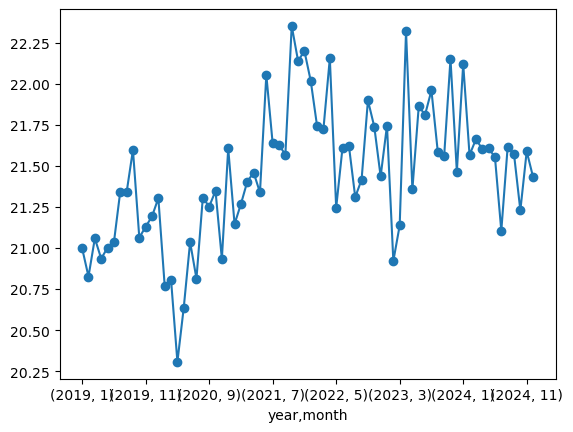

In [49]:
df_clean.groupby(["year", "month"])["avg_sentence_length"].mean().plot(marker="o")

<Axes: xlabel='year,month'>

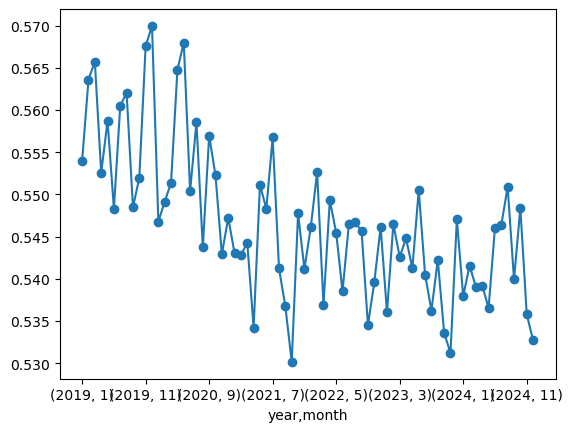

In [50]:
df_clean.groupby(["year", "month"])["burstiness"].mean().plot(marker="o")

<Axes: xlabel='year'>

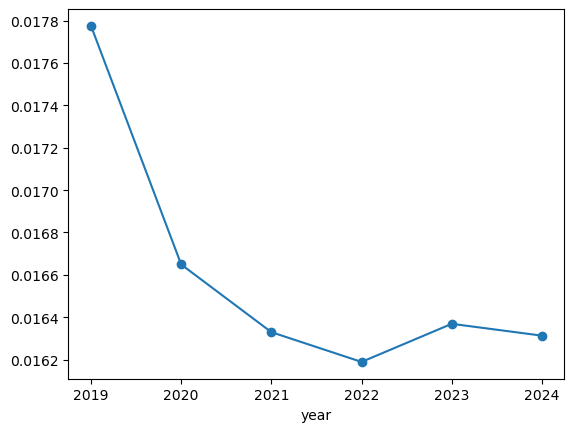

In [51]:
df_clean.groupby("year")["hedge_rate"].mean().plot(marker="o")

In [52]:
df_clean.to_csv("post_processing_opinion.csv", index=False)